In [50]:
title = "# Random variables and probability distributions: Exercises"
# Print title and setup TeX defs for both KaTeX and MathJax
import bayesian_stats_course_tools
bayesian_stats_course_tools.misc.display_markdown_and_setup_tex(title)

import matplotlib.style
matplotlib.style.use("bayesian_stats_course_tools.light")

import numpy as np
import matplotlib.pyplot as plt
import math 
import random as rand
import scipy

matplotlib.rcParams['figure.figsize'] = [4, 2]

# Random variables and probability distributions: Exercises

<!-- Define LaTeX macros -->
$\def\E{\operatorname{E}}$
$\def\Var{\operatorname{Var}}$
$\def\Cov{\operatorname{Cov}}$
$\def\dd{\mathrm{d}}$
$\def\ee{\mathrm{e}}$
$\def\Norm{\mathcal{N}}$
$\def\Uniform{\mathcal{U}}$
$\def\GP{\mathcal{GP}}$

<!-- MathJax needs them to be defined again for the non-inline environment -->
$$\def\E{\operatorname{E}}$$
$$\def\Var{\operatorname{Var}}$$
$$\def\Cov{\operatorname{Cov}}$$
$$\def\dd{\mathrm{d}}$$
$$\def\ee{\mathrm{e}}$$
$$\def\Norm{\mathcal{N}}$$
$$\def\Uniform{\mathcal{U}}$$
$$\def\GP{\mathcal{GP}}$$

### Exercise 1

Consider the distribution with PDF
$$
    p(x) = \begin{cases}
                \frac{1}{2}\sin x & 0 \le x \le \pi \\
                0 & \text{otherwise}
            \end{cases}
$$

1. Derive the CDF $F(x) = \int_{-\infty}^{x} p(x')\,\dd x'$ analytically, and plot it together with the PDF $p(x)$.
2. Find the inverse CDF $F^{-1}(u)$, and use it to transform samples $U \sim \Uniform(0, 1)$ into samples $X = F^{-1}(U)$ (inverse transform sampling).
3. Compare a density-normalised histogram of the samples with the PDF $p(x)$.

In [68]:
def p(x):
    result = (1/2)*math.sin(x)
    return float(result)

def cdf(x):
    result = (1/2)*(1-math.cos(x))
    return float(result)

print(p(0), cdf(0))

0.0 0.0


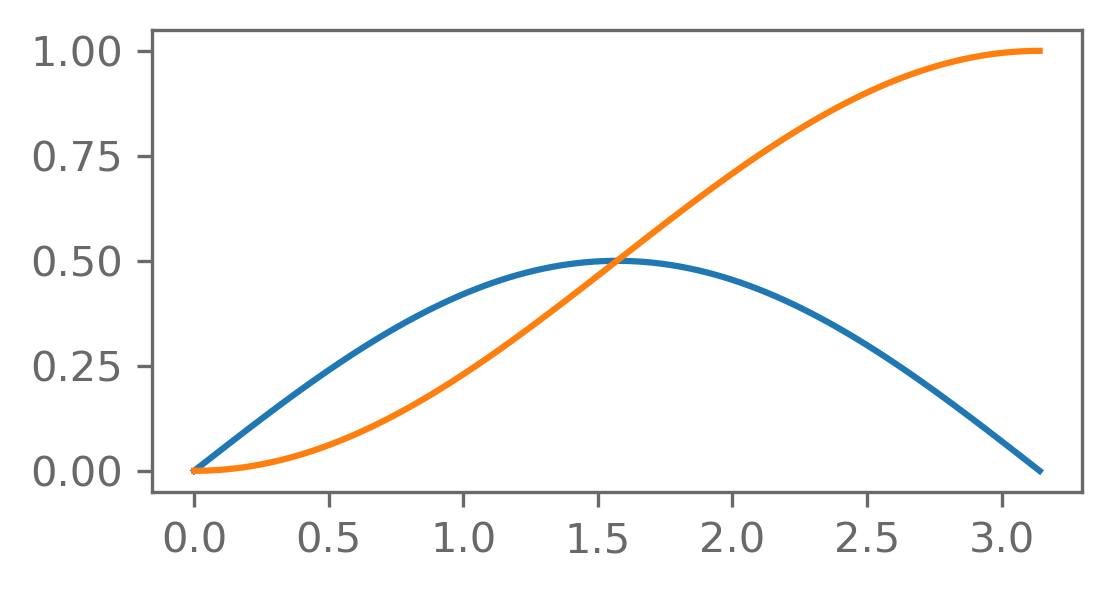

In [69]:
x = np.linspace(0, np.pi, 100)
p_x = [p(val) for val in x]
cdf_x = [cdf(val) for val in x]

plt.plot(x,p_x)
plt.plot(x,cdf_x)

In [70]:
def inv_cdf(x):
    return math.acos(1-2*x)

inv_cdf(0)

0.0

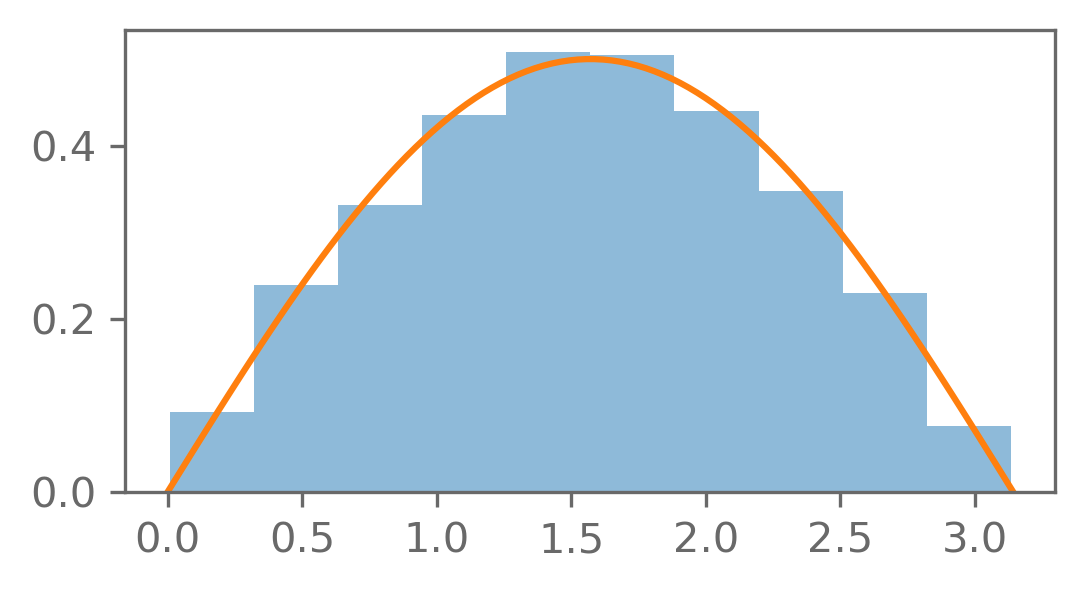

In [71]:
n=10000

sample = [inv_cdf(rand.random()) for _ in range(n)]

plt.hist(sample, alpha=0.5, density=True)
plt.plot(x,p_x)

In [66]:
bins, values = np.histogram(sample)
norm_factor = 1/sum(values)

bins

norm_values = values * norm_factor
norm_values

#plt.scatter(bins, norm_values)

array([0.000729  , 0.01876502, 0.03680104, 0.05483705, 0.07287307,
       0.09090909, 0.10894511, 0.12698113, 0.14501715, 0.16305316,
       0.18108918])

### Exercise 2

Consider a random variable with distribution $p(x)$, mean $\E[x] = \mu$ and variance $\Var[x] = \sigma^2$, and let $a$ and $c$ be constants. Using the definition of the expectation,
$$
    \E(f(x)) = \int_{-\infty}^\infty f(x)\, p(x) \dd x \,,
$$
show that:

**Mean**

1. $\E[x + a] = \mu + a$
2. $\E[cx] = c\mu$

**Variance**

3. $\Var[x] = \E[(x - \E[x])^2] = \E[x^2] - \E[x]^2$
4. $\Var[x + a] = \sigma^2$
5. $\Var[cx] = c^2\sigma^2$

*Hint:* use the linearity of the expectation (results 1 and 2) to prove results 3–5.

### Exercise 3

Let $X_1, \dots, X_n$ be $n$ i.i.d. random variables with $X_i \sim \Uniform(0, 1)$, and let $K$ be the number of them that fall into a small interval of width $\Delta x$.

1. Confirm by simulation that, for large $n$ and small $\Delta x$ with the rate $\lambda = n\,\Delta x$ held fixed, $K$ follows a Poisson distribution:
$$
    \Pr(K = k) = \frac{\lambda^k}{k!}\ee^{-\lambda}
$$
2. Derive the Poisson distribution from the binomial distribution, $\Pr(K = k) = \binom{n}{k}p^k(1-p)^{n-k}$, in the limit $n \to \infty$ with $np = \lambda$ held fixed.

In [72]:
repeat=10000
n = 1000
K = []
delta = 0.01
rate = delta*n
for _ in range(repeat):
    sample = [rand.random() for _ in range(n)]
    
    in_range = [value for value in sample if value <= delta]
    
    K.append(len(in_range))

(array([0.00000000e+00, 2.00040008e-04, 2.00040008e-03, 8.00160032e-03,
        1.84036807e-02, 3.87077415e-02, 6.51130226e-02, 9.23184637e-02,
        1.07621524e-01, 1.20824165e-01, 1.28425685e-01, 1.12922585e-01,
        9.57191438e-02, 7.60152030e-02, 5.36107221e-02, 3.21064213e-02,
        2.12042408e-02, 1.29025805e-02, 7.10142028e-03, 3.20064013e-03,
        2.10042008e-03, 7.00140028e-04, 7.00140028e-04, 1.00020004e-04]),
 array([-0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5,
        10.5, 11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5,
        21.5, 22.5, 23.5]),
 <BarContainer object of 24 artists>)

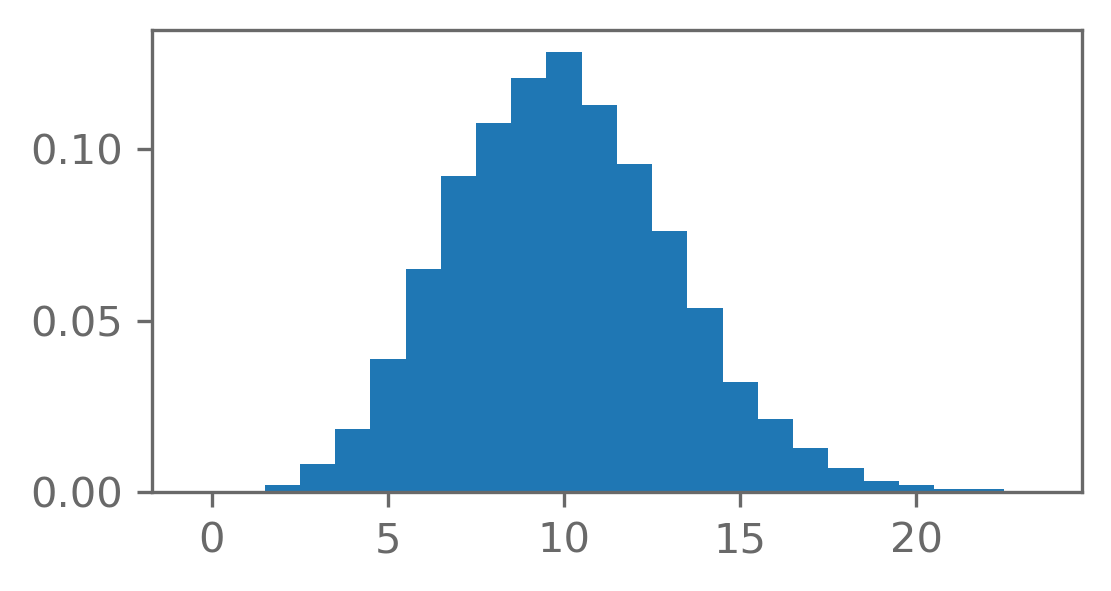

In [73]:
k = np.arange(24)
plt.hist(K, bins=np.arange(25)-0.5, density=True)


(array([0.00000000e+00, 2.00040008e-04, 2.00040008e-03, 8.00160032e-03,
        1.84036807e-02, 3.87077415e-02, 6.51130226e-02, 9.23184637e-02,
        1.07621524e-01, 1.20824165e-01, 1.28425685e-01, 1.12922585e-01,
        9.57191438e-02, 7.60152030e-02, 5.36107221e-02, 3.21064213e-02,
        2.12042408e-02, 1.29025805e-02, 7.10142028e-03, 3.20064013e-03,
        2.10042008e-03, 7.00140028e-04, 7.00140028e-04, 1.00020004e-04]),
 array([-0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5,
        10.5, 11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5,
        21.5, 22.5, 23.5]),
 <BarContainer object of 24 artists>)

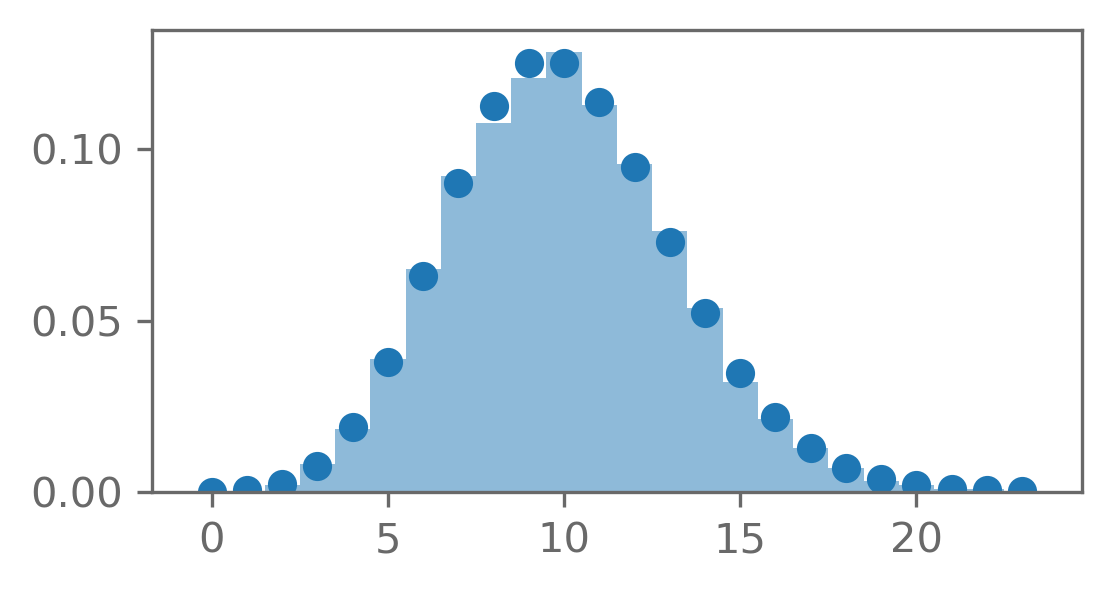

In [74]:
k = np.arange(24)
plt.plot(k, scipy.stats.poisson(rate).pmf(k), "o", c="C0", label=rf"PMF $\mathrm{{Poisson}}(\lambda={rate:g})$")
plt.hist(K, bins=np.arange(25)-0.5, density=True,alpha=0.5)

### Exercise 4

1. Make plots of the PDFs of the distributions covered in the lecture, varying their parameters (e.g., vary one parameter at a time while keeping the others fixed: for the normal distribution, plot $\Norm(\mu, 1)$ for three values of $\mu$, and $\Norm(0, \sigma^2)$ for three values of $\sigma^2$). For discrete distributions, such as the binomial and Poisson, plot the PMF instead.
2. Compute the distribution of the sum $Z = X + Y$ of two independent Gaussian RVs $X \sim \Norm(\mu_X, \sigma_X^2)$ and $Y \sim \Norm(\mu_Y, \sigma_Y^2)$.
   *Hint:* the lecture states that sums of Gaussian RVs are Gaussian, and a Gaussian is completely determined by its mean and variance, so it is enough to compute $\E[Z]$ and $\Var[Z]$. Independence means that the joint PDF factorises, $p_{XY}(x, y) = p_X(x)\,p_Y(y)$.
3. What is the distribution of the sum $Z = X + Y$ of two independent RVs $X \sim p_X$ and $Y \sim p_Y$?
4. Derive the PDF of the $\chi^2_{\nu=1}$ distribution, i.e., of $Z = X^2$ with $X \sim \Norm(0, 1)$.

**Bonus**

5. What is the distribution of the product $Z = UV$ of two independent RVs $U$ and $V$?
6. Compute the distribution of the ratio of two independent Gaussian RVs.